# EDA — AI vs. Human Text (SEA 820 · AITrace)

**Goal of this notebook:** understand the dataset *before* modeling so our preprocessing,
split, and metric choices are evidence-based — not guesses.

Every step below states **what** it computes and **what value / decision** it informs.

| Step | What we look at | Why it matters (value) |
|---|---|---|
| 1 | Class distribution | Imbalance -> stratify the split, report F1 not just accuracy |
| 2 | Nulls / duplicates | Prevent train/test leakage and noise |
| 3 | Text length (chars/words) | Is length itself a human-vs-AI signal? Sets TF-IDF & truncation choices |
| 4 | Sentence structure | AI text is often more uniform — a possible feature |
| 5 | Sub-word length vs 512 | How many essays DistilBERT would truncate |
| 6 | Vocabulary | Vocab size + words that distinguish the two classes |
| 7 | Preprocessing preview | Sanity-check the shared pipeline output |


## 0. Setup (Google Colab + Drive)

**What:** mount Google Drive and point to the dataset there, then import the *shared*
`preprocessing.py`.
**Value:** Colab gives us the RAM to load the full ~1 GB file, and reading from Drive means the
dataset (and later the canonical split) persists across sessions and is shared by both members —
reusing `preprocessing.py` guarantees EDA sees exactly what the models will see.

In [3]:
import os, sys, collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

# Folder in  Drive that holds BOTH AI_Human.csv and preprocessing.py

DRIVE_DIR = '/content/drive/MyDrive/NLP_project'
DATA_PATH = os.path.join(DRIVE_DIR, 'AI_Human.csv')
assert os.path.exists(DATA_PATH), f'Dataset not found at {DATA_PATH} — check DRIVE_DIR'

sys.path.append(DRIVE_DIR)  # import the shared preprocessing.py from Drive
import preprocessing as prep

pd.set_option('display.max_colwidth', 120)
SEED = 42
LABELS = {0: 'Human', 1: 'AI'}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Class distribution (full dataset)

**What:** count human (0) vs AI (1) across ALL 487k rows using a memory-safe chunked pass.
**Value:** the balance decides two things — (a) we must **stratify** every split so the ratio is
preserved, and (b) **accuracy alone is misleading** on imbalanced data, so we lead with
precision / recall / F1.

Human  (label 0):  305,797  (62.8%)
AI     (label 1):  181,438  (37.2%)
TOTAL           :  487,235


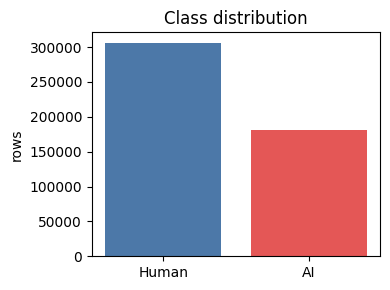

In [4]:
counts = collections.Counter()
for chunk in pd.read_csv(DATA_PATH, usecols=['generated'], chunksize=100_000):
    lab = chunk['generated'].astype(float).round().astype(int)
    counts.update(lab.value_counts().to_dict())

total = sum(counts.values())
for k in sorted(counts):
    print(f'{LABELS[k]:6s} (label {k}): {counts[k]:>8,}  ({counts[k]/total:.1%})')
print(f'{"TOTAL":6s}          : {total:>8,}')

plt.figure(figsize=(4,3))
plt.bar([LABELS[k] for k in sorted(counts)], [counts[k] for k in sorted(counts)],
        color=['#4C78A8', '#E45756'])
plt.title('Class distribution'); plt.ylabel('rows'); plt.tight_layout(); plt.show()

## 2. Load a working sample + data hygiene

**What:** the full text column is ~1 GB. For text-level analysis we load a **stratified sample**
(fast, representative) and check for nulls and exact duplicates.
**Value:** duplicates that land in both train and test would inflate scores (leakage); we confirm
how many exist so `data_split.py` is right to drop them.

In [5]:
SAMPLE_N = 40_000  # representative subset for text analysis

# Read full text once, then stratified-sample (kept simple; drop if RAM-limited).
df = pd.read_csv(DATA_PATH, usecols=['text', 'generated'])
df['label'] = df['generated'].astype(float).round().astype(int)
df['text'] = df['text'].astype(str)

n_dupe = df.duplicated(subset=['text']).sum()
n_blank = (df['text'].str.strip().str.len() == 0).sum()
print(f'Exact duplicate texts : {n_dupe:,}')
print(f'Blank/empty texts     : {n_blank:,}')

df = df.drop_duplicates(subset=['text'])
df = df[df['text'].str.strip().str.len() > 0]

# Stratified downsample: equal-sized draw per class.
per_class = min(SAMPLE_N // 2, df['label'].value_counts().min())
df = (df.groupby('label', group_keys=False)
        .sample(n=per_class, random_state=SEED)
        .reset_index(drop=True))
print(f'Working sample: {len(df):,} rows '
      f'({(df.label==0).mean():.0%} human / {(df.label==1).mean():.0%} AI)')

Exact duplicate texts : 0
Blank/empty texts     : 4
Working sample: 40,000 rows (50% human / 50% AI)


## 3. Text length — characters & words

**What:** distribution of character count and word count, split by class.
**Value:** if AI and human essays differ systematically in length, **length itself is a signal**
the classical model can exploit. It also guides TF-IDF (very short docs are weak) and warns us
about very long docs that the Transformer will have to truncate.

label                0        1
n_chars count  20000.0  20000.0
        mean    2346.2   2140.4
        std     1072.0    785.2
        min      458.0      1.0
        25%     1543.0   1671.8
        50%     2147.0   2061.0
        75%     2909.0   2490.0
        max     8058.0   8104.0
n_words count  20000.0  20000.0
        mean     420.7    346.7
        std      185.5    116.8
        min       84.0      1.0
        25%      281.0    276.0
        50%      388.0    339.0
        75%      518.0    405.0
        max     1368.0   1145.0


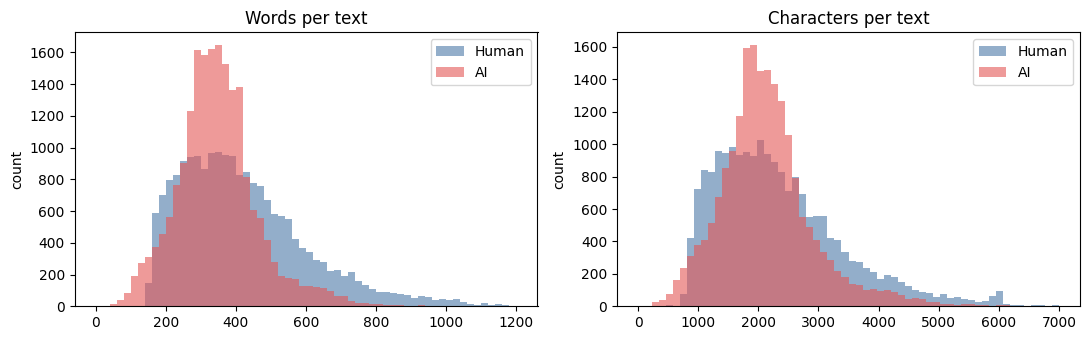

In [6]:
df['n_chars'] = df['text'].str.len()
df['n_words'] = df['text'].str.split().map(len)

print(df.groupby('label')[['n_chars', 'n_words']].describe().round(1).T)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for lab, color in [(0, '#4C78A8'), (1, '#E45756')]:
    axes[0].hist(df[df.label==lab]['n_words'], bins=60, alpha=0.6,
                 label=LABELS[lab], color=color, range=(0, 1200))
    axes[1].hist(df[df.label==lab]['n_chars'], bins=60, alpha=0.6,
                 label=LABELS[lab], color=color, range=(0, 7000))
axes[0].set_title('Words per text'); axes[1].set_title('Characters per text')
for ax in axes: ax.legend(); ax.set_ylabel('count')
plt.tight_layout(); plt.show()

## 4. Sentence structure

**What:** number of sentences per text and average words per sentence (on a small sub-sample,
since sentence tokenization is slower).
**Value:** AI-generated text is often **more uniform** in sentence length/structure than human
writing. If we see that here, it becomes a candidate hand-crafted feature and a talking point in
the report's error analysis.

       n_sents  avg_words_per_sent
label                             
0         21.3                21.6
1         18.6                19.3


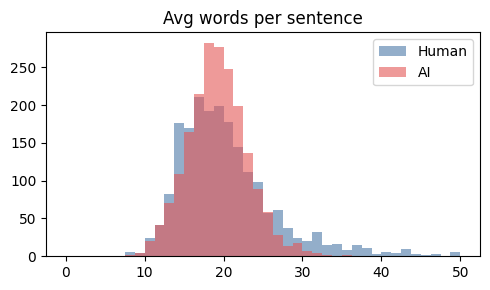

In [7]:
sub = df.sample(min(4000, len(df)), random_state=SEED).copy()
sub['n_sents'] = sub['text'].map(lambda t: len(prep.tokenize_sentences(t)))  # tokenize once
sub['avg_words_per_sent'] = sub['n_words'] / sub['n_sents'].clip(lower=1)

print(sub.groupby('label')[['n_sents', 'avg_words_per_sent']].mean().round(1))

plt.figure(figsize=(5,3))
for lab, color in [(0, '#4C78A8'), (1, '#E45756')]:
    plt.hist(sub[sub.label==lab]['avg_words_per_sent'], bins=40, alpha=0.6,
             label=LABELS[lab], color=color, range=(0, 50))
plt.title('Avg words per sentence'); plt.legend(); plt.tight_layout(); plt.show()

## 5. Sub-word length vs. the 512-token limit

**What:** tokenize a sub-sample with DistilBERT's own WordPiece tokenizer and see how many texts
exceed **512** sub-word tokens.
**Value:** DistilBERT can only read 512 tokens at once. Knowing the % that overflow tells Member B
whether truncation will lose a lot of content and whether `max_length` should be 256/384/512.
*(Requires `transformers`; skipped gracefully if not installed.)*

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (583 > 512). Running this sequence through the model will result in indexing errors


        mean    50%     max
label                      
0      483.0  446.0  1494.0
1      419.0  407.0  1101.0

Texts exceeding 512 sub-word tokens: 28.5% -> these would be truncated by DistilBERT


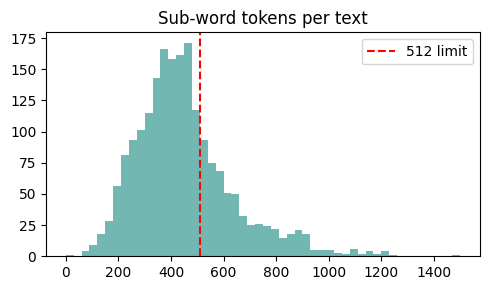

In [8]:
try:
    sub2 = df.sample(min(2000, len(df)), random_state=SEED).copy()
    sub2['n_subword'] = sub2['text'].map(lambda t: len(prep.tokenize_subword(t)))
    over = (sub2['n_subword'] > 512).mean()
    print(sub2.groupby('label')['n_subword'].describe().round(0)[['mean','50%','max']])
    print(f'\nTexts exceeding 512 sub-word tokens: {over:.1%} '
          f'-> these would be truncated by DistilBERT')
    plt.figure(figsize=(5,3))
    plt.hist(sub2['n_subword'], bins=50, color='#72B7B2', range=(0, 1500))
    plt.axvline(512, color='red', ls='--', label='512 limit')
    plt.title('Sub-word tokens per text'); plt.legend(); plt.tight_layout(); plt.show()
except Exception as e:
    print('Skipped sub-word analysis (transformers not installed):', e)

## 6. Vocabulary analysis

**What:** using the shared classical pipeline (lowercase, de-punct, de-stopword, lemmatize),
compute vocabulary size and the most frequent content words **per class**, then find words that
are **distinctive** to each class (high frequency in one, low in the other).
**Value:** this is the human-interpretable core — it previews *what the TF-IDF model will latch
onto* and gives concrete examples for the report ("AI text over-uses word X").

In [9]:
voc = df.sample(min(15000, len(df)), random_state=SEED).copy()
voc['tokens'] = voc['text'].map(lambda t: prep.classical_preprocess(t, return_tokens=True))

def top_words(mask, n=20):
    c = collections.Counter()
    for toks in voc[mask]['tokens']: c.update(toks)
    return c

human_c = top_words(voc.label == 0)
ai_c    = top_words(voc.label == 1)
all_vocab = set(human_c) | set(ai_c)
print(f'Vocabulary size (sample, after cleaning): {len(all_vocab):,} unique tokens\n')

print('Top 15 human words:', [w for w,_ in human_c.most_common(15)])
print('Top 15 AI words   :', [w for w,_ in ai_c.most_common(15)])

Vocabulary size (sample, after cleaning): 37,330 unique tokens

Top 15 human words: ['student', 'car', 'people', 'would', 'school', 'get', 'time', 'could', 'one', 'like', 'help', 'vote', 'also', 'make', 'many']
Top 15 AI words   : ['student', 'car', 'people', 'also', 'electoral', 'help', 'college', 'state', 'like', 'may', 'time', 'life', 'school', 'make', 'one']


**Distinctive words** — ratio of normalized frequency in one class vs the other.
**Value:** words at the extremes are the strongest human-vs-AI cues; expect these to be top TF-IDF
features and to explain many of the model's decisions.

In [10]:
h_tot, a_tot = sum(human_c.values()), sum(ai_c.values())
rows = []
for w in all_vocab:
    hf = human_c.get(w, 0) / h_tot
    af = ai_c.get(w, 0) / a_tot
    if human_c.get(w,0) + ai_c.get(w,0) < 30:  # ignore rare noise
        continue
    rows.append((w, af / (hf + 1e-9), hf / (af + 1e-9)))
vdf = pd.DataFrame(rows, columns=['word', 'ai_over_human', 'human_over_ai'])
print('Most AI-distinctive words:')
print(vdf.sort_values('ai_over_human', ascending=False).head(15)[['word','ai_over_human']].to_string(index=False))
print('\nMost human-distinctive words:')
print(vdf.sort_values('human_over_ai', ascending=False).head(15)[['word','human_over_ai']].to_string(index=False))

Most AI-distinctive words:
            word  ai_over_human
             zip  130667.260315
     mindfulness  124445.009824
  sustainability  118914.120499
       inclusive  103704.174854
disproportionate   98173.285528
         hillary   93333.757368
      vegetarian   71901.561232
          sprawl   68444.755403
    intervention   67753.394238
         johnson   64987.949575
        decisive   63605.227244
           ekman   61531.143746
           blake   59457.060249
       surfboard   59457.060249
       framework   53234.809758

Most human-distinctive words:
      word  human_over_ai
 driveless  160468.165874
     wreck  137902.330048
     gavin  106560.891401
     kerry   83368.226802
   ordered   75846.281526
   silicon   64563.363613
       jpl   63936.534840
   fencing   63936.534840
     unrwa   62682.877295
   carbide   60175.562203
survivable   59548.733430
 acropolis   57668.247111
 microgram   57041.418338
   bloomed   57041.418338
      alot   56414.589565


## 7. Preprocessing preview

**What:** show one example through each stage of the shared pipeline.
**Value:** a sanity check that `preprocessing.py` behaves as intended and a clear before/after
for the report's Methods section.

In [11]:
ex = df['text'].iloc[0][:400]
print('RAW           :', ex, '...\n')
print('basic_clean   :', prep.basic_clean(ex)[:300], '...\n')
print('classical(lem):', prep.classical_preprocess(ex)[:300], '...\n')
print('transformer   :', prep.transformer_text(ex)[:300], '...')

RAW           : Do curfews keep teenagers from Getting into trouble? The city council is still currently debating on either adopting the curfew to be at 10 p. m. during the week days or at midnight on the weekends. If teenagers were to be out after the hours selected, it would be considered breaking the law. The laws are choose for many reasons, even if we don't tree with most of them; we have to obey the laws. I ...

basic_clean   : Do curfews keep teenagers from Getting into trouble? The city council is still currently debating on either adopting the curfew to be at 10 p. m. during the week days or at midnight on the weekends. If teenagers were to be out after the hours selected, it would be considered breaking the law. The la ...

classical(lem): curfew keep teenager getting trouble city council still currently debating either adopting curfew week day midnight weekend teenager hour selected would considered breaking law law choose many reason even tree obey law ...

transformer   : 

## 8. Summary of Findings & Modeling Decisions

*Computed on the full dataset (class balance) and a 40,000-row class-balanced sample (text analysis).*

### Key numbers

| Finding | Result | Decision it drives |
|---|---|---|
| **Class balance** | 305,797 human (62.8%) / 181,438 AI (37.2%), n=487,235 | Imbalanced → **stratify** every split; report **F1**, not just accuracy |
| **Data hygiene** | **0** exact duplicates, **4** blank texts | Dataset is clean; only blanks dropped — negligible leakage risk |
| **Word count** | Human mean **420** (median 388) vs AI mean **347** (median 339) | Human essays run **longer**; length is a usable classical feature |
| **Length variability** | Human std **185** vs AI std **117** | AI text is **more uniform**; human writing more variable |
| **Very short texts** | AI min = **1** word; human min = **84** | Some AI samples are tiny → watch these in error analysis |
| **Sentences** | Human **21.3** sents / **21.6** words-per-sent vs AI **18.6** / **19.3** | Reinforces "AI is more uniform / slightly shorter" |
| **Sub-word length** | **28.5%** of texts exceed 512 DistilBERT tokens (max ~1494) | Non-trivial truncation → fine-tune with **`max_length=512`** to keep the most content |
| **Vocabulary** | 37,330 unique cleaned tokens | Heavy topic overlap (student, car, school) — the signal is in *distinctive* words |

### What distinguishes the classes (most valuable insight)

- **AI over-uses abstract / formal vocabulary:** `sustainability`, `mindfulness`, `inclusive`,
  `disproportionate`, `intervention`, `framework`, `decisive`. This matches the "polished,
  elevated register" of LLM writing.
- **Humans produce misspellings and informal tokens:** `driveless` (for *driverless*), `alot`,
  plus varied concrete/proper nouns (`gavin`, `kerry`, `silicon`, `fencing`). **Misspellings are a
  strong human signal** — LLMs rarely make them.

> ⚠️ **Ethics flag (for the report):** if the model leans on "clean spelling/formal vocabulary =
> AI", it will likely **misclassify careful or non-native writers as AI**. Note this for the
> ethical-considerations section and error analysis.

### Decisions carried into modeling
1. **Split:** stratified train/val/test (already implemented in `data_split.py`, seed=42).
2. **Headline metric:** F1 (with precision/recall), because of the 63/37 imbalance.
3. **Classical model:** TF-IDF on the cleaned text; expect distinctive/abstract words + length to
   carry signal. Worth adding length as an extra feature (feature-engineering bonus).
4. **Transformer:** DistilBERT with `max_length=512` (≈28.5% of texts truncated — acceptable;
   shorter limits would truncate far more).

### Sanity check
The shared pipeline behaves as intended: `classical_preprocess` reduces text to lemmatized content
words for TF-IDF, while `transformer_text` preserves casing/punctuation for DistilBERT — confirming
one dataset can feed both models fairly.